# Shared PyTorch DataLoader

**Everyone imports from this notebook** so models see exactly the same
inputs. Configure these four things:

| Parameter | What it controls |
|---|---|
| `features` | Which columns the model sees (see table below) |
| `input_len` | How many past steps the model sees |
| `target_len` | How many future steps to predict |
| `stride` | How far the sliding window advances between samples |

**Inputs** (produced by the earlier notebooks):

- `processed/ais_trajectories_{TIMESTEP}min.parquet` ← `generate_trajectories.ipynb`
- `processed/splits.parquet`                         ← `make_splits.ipynb`
- `processed/feature_stats.csv`                      ← `make_splits.ipynb`

**Output shape per batch**:
```
x: (batch, input_len,  n_features)    # normalized
y: (batch, target_len, n_features)
```
where `n_features` depends on the feature list you pick (angular features
like `cog` expand into 2 columns).

## 1. Imports and configuration

In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import json
import time
from datetime import datetime

OUT_DIR = "processed"

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  >>> Match the timestep of the parquet file you're using <<<         ║
# ╚══════════════════════════════════════════════════════════════════════╝
TIMESTEP_MIN = 3
REGION = "West Coast"
INTERP_FILE  = f"{OUT_DIR}/ais_trajectories_{REGION}_{TIMESTEP_MIN}min.parquet"
SPLITS_FILE  = f"{OUT_DIR}/splits_{REGION}_{TIMESTEP_MIN}min.parquet"
STATS_FILE   = f"{OUT_DIR}/feature_stats_{REGION}_{TIMESTEP_MIN}min.csv"

## 2. Feature registry

Available features and how they're encoded before going into the model.
The columns come from `ais_trajectories_{TIMESTEP}min.parquet` (19 columns).

| Key | Parquet column | Encoding | Output dims |
|---|---|---|---|
| `lat` | `latitude`  | z-score normalize | 1 |
| `lon` | `longitude` | z-score normalize | 1 |
| `sog` | `sog`       | z-score normalize | 1 |
| `cog` | `cog`       | angular → cos, sin | **2** (`cog_cos`, `cog_sin`) |
| `heading` | `heading` | angular → cos, sin | **2** |
| `length` | `length` | z-score normalize | 1 |
| `width`  | `width`  | z-score normalize | 1 |
| `draft`  | `draft`  | z-score normalize | 1 |

- **Angular** features (`cog`, `heading`) are split into cosine + sine to
  handle the 0°/360° wraparound. They're already in [−1, 1], no normalize.
- **z-score** means `(x - mean) / std` using train-only stats from
  `feature_stats.csv`. NaNs become 0 after normalization (≈ feature mean).
- Categorical columns (vessel_type, transceiver, status) are NOT exposed
  here — add them if your group decides they help. Most AIS prediction
  papers use only position / speed / course.

**Default feature set**: `["lat", "lon", "sog", "cog"]` → 5 model columns
(matches what the reference papers use).

In [2]:
FEATURE_REGISTRY = {
    "lat":     {"col": "latitude",  "encoding": "normalize"},
    "lon":     {"col": "longitude", "encoding": "normalize"},
    "sog":     {"col": "sog",       "encoding": "normalize"},
    "cog":     {"col": "cog",       "encoding": "angular"},
    "heading": {"col": "heading",   "encoding": "angular"},
    "length":  {"col": "length",    "encoding": "normalize"},
    "width":   {"col": "width",     "encoding": "normalize"},
    "draft":   {"col": "draft",     "encoding": "normalize"},
}

DEFAULT_FEATURES = ["lat", "lon", "sog", "cog", "heading"]   # → 7 columns
# DEFAULT_FEATURES = ["lat", "lon", "sog", "cog"]   # → 5 columns

# Position encoding for lat/lon. Two options:
#
#   "relative" (default, recommended for LSTM/Transformer):
#       Each window's lat/lon are stored as DISPLACEMENT IN KILOMETERS from
#       the last input timestep, using a local equirectangular projection
#       around the reference latitude:
#           Δlat_km = (lat_deg - ref_lat_deg) * 111.320
#           Δlon_km = (lon_deg - ref_lon_deg) * 111.320 * cos(ref_lat_rad)
#       The model becomes both location-invariant AND scale-consistent: a
#       1-km step north and a 1-km step east are the same magnitude in
#       feature space, regardless of latitude. Loss in km is directly
#       comparable to the haversine evaluation metric (within <1% over
#       <100 km windows).
#       Predictions are also in km space; recover absolute lat/lon with
#       `dataset.recover_absolute(i, delta_km)` (or, for a specific window,
#       `reference_latlon(i)` returns the anchor in degrees and you can
#       invert the projection yourself).
#
#   "absolute":
#       Lat/lon are z-scored against the global train mean/std, like all
#       other normalized features. The model has to memorize the
#       coastline geography to predict positions. Use only if you have a
#       specific reason — relative is strictly better for trajectory
#       forecasting under almost all settings.
DEFAULT_POSITION_ENCODING = "relative"

# Some features weren't included in feature_stats.csv (only lat/lon/sog/cog/heading
# were). We can either re-read the parquet to compute stats for extra columns,
# or require the user to only use features that have stats. For group simplicity,
# we compute stats on the fly for any numeric feature not already in the file.

POSITION_FEATURES = {"lat", "lon"}   # which feature keys are positions

# Equirectangular projection constant. 1° of latitude ≈ 111.320 km on a sphere
# of mean Earth radius. 1° of longitude ≈ 111.320 × cos(lat) km — the cosine
# factor is per-window using the reference (last-input-timestep) latitude.
KM_PER_DEG_LAT = 111.320

## 3. The `AISDataset` class

One instance = one split (train / val / test). Responsibilities:

1. Load the parquet, filter to the requested split via `splits.parquet`.
2. Sort rows so each trip is contiguous and time-ordered.
3. Build a `(N, n_features)` float32 array with the selected features
   (normalized / angular-encoded as appropriate).
4. Precompute `(start, end)` index pairs for every valid sliding window.
   Windows never cross trip boundaries.
5. `__getitem__(i)` slices window `i` — cheap, no data copied until needed.

In [3]:
class AISDataset(Dataset):
    def __init__(self, split, features=None,
                 input_len=20, target_len=20, stride=5,
                 position_encoding=DEFAULT_POSITION_ENCODING):
        """
        Args:
            split:              "train", "val", or "test"
            features:           list of feature keys from FEATURE_REGISTRY.
                                Default = ["lat","lon","sog","cog","heading"]
                                → 7 model columns (cog, heading expand to cos/sin).
            input_len:          # past steps per sample (default 20 = 1 hr).
            target_len:         # future steps per sample.
            stride:             sliding step between consecutive samples.
                                stride=1 = max overlap; stride=target_len = no overlap.
                                Default 5 = 15-min spacing (good train/eval middle
                                ground; cuts redundant samples ~5x vs stride=1).
            position_encoding:  "relative" (default) or "absolute".
                                See module-level docstring near DEFAULT_POSITION_ENCODING.
        """
        assert split in ("train", "val", "test")
        assert position_encoding in ("relative", "absolute")
        features = features or DEFAULT_FEATURES
        for f in features:
            if f not in FEATURE_REGISTRY:
                raise ValueError(
                    f"Unknown feature '{f}'. Available: {list(FEATURE_REGISTRY)}"
                )

        self.split = split
        self.features = features
        self.input_len = input_len
        self.target_len = target_len
        self.stride = stride
        self.window = input_len + target_len
        self.position_encoding = position_encoding

        # ── Load + filter data ──
        df = pd.read_parquet(INTERP_FILE)
        splits = pd.read_parquet(SPLITS_FILE)
        keep_mmsi = splits.loc[splits["split"] == split, "mmsi"].to_numpy()
        df = df[df["mmsi"].isin(keep_mmsi)].copy()
        df = df.sort_values(["trip_id", "base_date_time"]).reset_index(drop=True)

        # ── Load / compute normalization stats ──
        self.mean, self.std = self._load_stats(features, df)

        # ── Build the feature matrix and the model-feature column names ──
        self.feature_array, self.output_names, self.relative_col_idx = (
            self._build_features(df, features)
        )
        self.n_features = self.feature_array.shape[1]

        # ── Precompute sliding-window indices ──
        self.windows = self._build_windows(df)

        # ── Cache reference (lat, lon) per window (last input timestep, raw deg).
        #    Used by reference_latlon(i) — only meaningful when lat/lon are in
        #    the feature set under "relative" mode, but we always populate so
        #    the helper works regardless.
        if "lat" in features and "lon" in features:
            lat_raw = df["latitude"].to_numpy(dtype=np.float32)
            lon_raw = df["longitude"].to_numpy(dtype=np.float32)
            ref_offsets = self.windows[:, 0] + self.input_len - 1
            self._ref_lat = lat_raw[ref_offsets]
            self._ref_lon = lon_raw[ref_offsets]
            # cos(ref_lat) per window for equirectangular Δlon→km conversion.
            self._cos_ref_lat = np.cos(np.deg2rad(self._ref_lat)).astype(np.float32)
        else:
            self._ref_lat = self._ref_lon = self._cos_ref_lat = None

        # ── Locate the lat/lon columns in the feature matrix (if relative).
        #    Used by __getitem__ to apply the per-window km conversion.
        self._lat_rel_col = None
        self._lon_rel_col = None
        for j, name in enumerate(self.output_names):
            if name == "lat_rel_km":
                self._lat_rel_col = j
            elif name == "lon_rel_km":
                self._lon_rel_col = j
        # Hard requirement for relative-km encoding: if lon is relative, lat
        # must also be present (we need cos(ref_lat) to convert Δlon→km).
        if self._lon_rel_col is not None and self._cos_ref_lat is None:
            raise ValueError(
                "position_encoding='relative' with 'lon' in features requires "
                "'lat' to also be in features (needed to compute cos(ref_lat) "
                "for the Δlon→km equirectangular conversion)."
            )

        print(f"[{split}] {len(df):,} rows, {df['trip_id'].nunique():,} trips, "
              f"{len(self.windows):,} windows   "
              f"features={self.output_names} (n={self.n_features})  "
              f"position_encoding={self.position_encoding}")

    # ------------------------------------------------------------------
    def _load_stats(self, features, df):
        """Load mean/std from feature_stats.csv; fall back to train-set stats."""
        try:
            stats = pd.read_csv(STATS_FILE, index_col=0)
            mean = stats["mean"].to_dict()
            std  = stats["std"].to_dict()
        except FileNotFoundError:
            mean, std = {}, {}

        # For any requested feature whose stats aren't in the file, compute
        # them now from the current (train/val/test) split. WARNING: val/test
        # should not drive stats — call this only if you regenerated stats.
        for f in features:
            cfg = FEATURE_REGISTRY[f]
            if cfg["encoding"] != "normalize":
                continue
            col = cfg["col"]
            if col not in mean:
                print(f"  WARNING: '{col}' not in feature_stats.csv — "
                      f"using current split stats (may leak if split != train)")
                mean[col] = df[col].mean()
                std[col]  = df[col].std()
        return mean, std

    def _build_features(self, df, features):
        """
        Build the (N, n_out) float32 feature matrix.

        Returns:
            arr:         the feature matrix
            names:       column labels (one per output column)
            rel_idx:     output column indices that are "relative position" —
                         these need per-window subtraction in __getitem__.
        """
        cols, names, rel_idx = [], [], []
        for f in features:
            cfg = FEATURE_REGISTRY[f]
            col = cfg["col"]
            vals = df[col].to_numpy(dtype=np.float64)

            if cfg["encoding"] == "normalize":
                if (f in POSITION_FEATURES
                        and self.position_encoding == "relative"):
                    # Store raw degrees; per-window subtraction AND degrees→km
                    # conversion happen in __getitem__ (the cosine factor for
                    # Δlon depends on the per-window reference latitude).
                    cols.append(vals)
                    names.append(f"{f}_rel_km")
                    rel_idx.append(len(cols) - 1)
                else:
                    mu, sd = self.mean[col], self.std[col]
                    sd = sd if sd > 1e-9 else 1.0   # guard against constant cols
                    cols.append((vals - mu) / sd)
                    names.append(f"{f}_norm")

            elif cfg["encoding"] == "angular":
                rad = np.deg2rad(vals)
                cols.append(np.cos(rad))
                cols.append(np.sin(rad))
                names.append(f"{f}_cos")
                names.append(f"{f}_sin")

            else:
                raise ValueError(f"Unknown encoding: {cfg['encoding']}")

        arr = np.stack(cols, axis=1).astype(np.float32)
        # NaN → 0 (mean for z-scored features; neutral for angular and relative)
        arr = np.nan_to_num(arr, nan=0.0)
        return arr, names, rel_idx

    def _build_windows(self, df):
        """Generate (start, end) index pairs — windows never cross trip boundaries."""
        windows = []
        for _, idxs in df.groupby("trip_id").indices.items():
            L = len(idxs)
            if L < self.window:
                continue
            start_global = idxs[0]
            max_start = L - self.window
            for s in range(0, max_start + 1, self.stride):
                gs = start_global + s
                windows.append((gs, gs + self.window))
        return np.asarray(windows, dtype=np.int64)

    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.windows)

    def __getitem__(self, i):
        start, end = self.windows[i]
        seq = self.feature_array[start:end]        # (window, n_features)

        if self.relative_col_idx:
            # Subtract reference (last input timestep) from relative-position
            # columns to get Δdegrees, then convert Δdegrees→Δkm using a
            # local equirectangular projection at the reference latitude.
            # We copy first so the underlying feature_array isn't mutated
            # across calls.
            seq = seq.copy()
            ref = seq[self.input_len - 1, self.relative_col_idx].copy()
            seq[:, self.relative_col_idx] -= ref

            if self._lat_rel_col is not None:
                seq[:, self._lat_rel_col] *= KM_PER_DEG_LAT
            if self._lon_rel_col is not None:
                seq[:, self._lon_rel_col] *= KM_PER_DEG_LAT * self._cos_ref_lat[i]

        x = seq[: self.input_len]                  # (input_len,  n_features)
        y = seq[self.input_len :]                  # (target_len, n_features)
        return torch.from_numpy(x), torch.from_numpy(y)

    # ------------------------------------------------------------------
    def reference_latlon(self, i):
        """Return (ref_lat, ref_lon) in absolute degrees for window `i`.

        This is the position at the last input timestep — i.e., what the
        model is predicting *from*. Under "relative" encoding, predictions
        are Δkm from this anchor; use `recover_absolute(i, delta_km)` to
        invert the projection.

        Only available when both `lat` and `lon` are in the feature list.
        Returns None if not.
        """
        if self._ref_lat is None:
            return None
        return float(self._ref_lat[i]), float(self._ref_lon[i])

    def recover_absolute(self, i, delta_km):
        """Convert a Δkm prediction for window `i` back to absolute (lat, lon) deg.

        Args:
            i:         window index
            delta_km:  array-like of shape (..., 2) with last dim = (Δlat_km, Δlon_km),
                       i.e. the model's prediction in the same space as `y`.

        Returns:
            (abs_lat_deg, abs_lon_deg) — each shape (...,) — absolute degrees.

        Inverts the equirectangular projection used in __getitem__:
            Δlat_deg = Δlat_km / 111.320
            Δlon_deg = Δlon_km / (111.320 * cos(ref_lat_rad))
        and adds the reference. Requires both `lat` and `lon` in features.
        """
        if self._ref_lat is None:
            raise ValueError(
                "recover_absolute requires both 'lat' and 'lon' in features."
            )
        delta_km = np.asarray(delta_km)
        ref_lat = float(self._ref_lat[i])
        ref_lon = float(self._ref_lon[i])
        cos_ref = float(self._cos_ref_lat[i])
        abs_lat = ref_lat + delta_km[..., 0] / KM_PER_DEG_LAT
        abs_lon = ref_lon + delta_km[..., 1] / (KM_PER_DEG_LAT * cos_ref)
        return abs_lat, abs_lon

## 4. Convenience helper: `get_dataloaders()`

Returns `(train, val, test)` DataLoaders — all use the same feature list,
input_len, target_len, and stride, so results are apples-to-apples.

Train-set rebalancing (dropping moored / drifting trips) happens upstream
in `make_splits.ipynb`, so this loader doesn't need to do anything special:
val and test still see the real distribution.

In [4]:
from torch.utils.data import Subset
from torch.utils.data import RandomSampler

def get_dataloaders(features=None,
                    input_len=20, target_len=20, stride=5,
                    batch_size=64, num_workers=0,
                    position_encoding=DEFAULT_POSITION_ENCODING,
                    train_subset_size=None,
                    val_subset_size=None):
    train_ds = AISDataset("train", features, input_len, target_len, stride,
                          position_encoding)
    val_ds   = AISDataset("val",   features, input_len, target_len, stride,
                          position_encoding)
    test_ds  = AISDataset("test",  features, input_len, target_len, stride,
                          position_encoding)

    if train_subset_size:
        sampler = RandomSampler(
            train_ds,
            replacement=False,
            num_samples=min(train_subset_size, len(train_ds))
        )
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False,
                                  sampler=sampler, num_workers=num_workers, 
                                  drop_last=True, pin_memory=True, persistent_workers=False)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, drop_last=True, 
                                  pin_memory=True, persistent_workers=False)
    if val_subset_size:
        np.random.seed(42)
        indices = np.random.choice(len(val_ds), size=val_subset_size, replace=False)
        val_ds = Subset(val_ds, indices)

    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers)

    print("After downsampling:")
    print(f"train_loader: {len(train_loader.dataset):,} windows")
    print(f"val_loader: {len(val_loader.dataset):,} windows")
    print(f"test_loader: {len(test_loader.dataset):,} windows")
    
    return train_loader, val_loader, test_loader

## 5. How your model code uses this

```python
from dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(batch_size=128)
n_features = train_loader.dataset.n_features

model = LSTMForecaster(n_features=n_features, hidden=128)
for x, y in train_loader:
    y_hat = model(x)                 # (B, target_len, n_features)
    loss = F.mse_loss(y_hat, y)      # loss is in km² ≈ haversine²
```

**If you specifically want absolute z-scored coords** (not recommended
for new models, but provided for compatibility):

```python
train_loader, val_loader, test_loader = get_dataloaders(
    position_encoding="absolute",
)
# Then to denormalize lat/lon predictions to degrees:
stats = pd.read_csv("processed/feature_stats.csv", index_col=0)
lat_deg = y_hat[..., 0].numpy() * stats.loc["latitude",  "std"] + stats.loc["latitude",  "mean"]
lon_deg = y_hat[..., 1].numpy() * stats.loc["longitude", "std"] + stats.loc["longitude", "mean"]
```

## 6. Transformer model (Build from scratch)

In [5]:
# checking system memory usage

import psutil
import os

# Get the memory usage of the current process in bytes
process = psutil.Process(os.getpid())
mem_info = process.memory_info()

# Convert bytes to Gigabytes for readability
current_mem = mem_info.rss / (1024 ** 3) 
total_mem = psutil.virtual_memory().total / (1024 ** 3)
used_mem_percent = psutil.virtual_memory().percent

print(f"Current Notebook Memory Usage: {current_mem:.2f} GB")
print(f"Total System Memory: {total_mem:.2f} GB")
print(f"Total System Memory Utilization: {used_mem_percent}%")

Current Notebook Memory Usage: 0.56 GB
Total System Memory: 186.69 GB
Total System Memory Utilization: 9.4%


In [6]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:x.size(1), :].unsqueeze(0)
        return x

class VesselTrajectoryTransformerQueryDecoder(nn.Module):
    def __init__(
        self,
        input_dim=5,
        target_len=20,
        target_dim=2,
        d_model=64,
        nhead=4,
        num_encoder_layers=4,
        num_decoder_layers=2,
        dim_feedforward=256,
        dropout=0.2,
    ):
        super().__init__()
        self.target_len = target_len
        self.target_dim = target_dim

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
        )

        self.future_queries = nn.Parameter(torch.randn(target_len, d_model) * 0.02)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_decoder_layers,
        )

        self.out = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, target_dim),
        )

    def forward(self, src):
        batch_size = src.size(0)

        memory = self.input_proj(src)
        memory = self.pos_encoder(memory)
        memory = self.encoder(memory)

        queries = self.future_queries.unsqueeze(0).expand(batch_size, -1, -1)
        queries = self.pos_encoder(queries)
        decoded = self.decoder(tgt=queries, memory=memory)

        return self.out(decoded)

In [7]:
import torch.optim as optim
import torch.nn.functional as F
import copy

def train_model(model, train_loader, val_loader, num_epochs=50, 
                lr=1e-4, device='cuda', use_scheduler=False, weight_decay=1e-4):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # optimizer = optim.Adam(model.parameters(), lr=lr)
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
    history = {'train_loss': [], 'val_loss': [], 'val_mde': []}

    # --- Best Model Tracking Variables ---
    best_val_mde = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            targets = targets[:, :, :2]
            inputs, targets = inputs.to(device), targets.to(device)
    
            optimizer.zero_grad()
            
            # Forward pass
            pred_pos = model(inputs)
            
            # Calculate loss
            loss = F.smooth_l1_loss(pred_pos, targets, beta=0.5)
            
            # Backward pass and optimize
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Prevent gradient explosion
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Validation Phase
        model.eval()
        total_val_loss = 0.0
        total_val_mde = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                targets = targets[:, :, :2]
                inputs, targets = inputs.to(device), targets.to(device)
                seq_len = inputs.size(1)
                pred_pos = model(inputs)
                val_loss = F.smooth_l1_loss(pred_pos, targets, beta=0.5)
                total_val_loss += val_loss.item()
                mde = torch.sqrt(torch.sum((pred_pos - targets)**2, dim=-1) + 1e-8).mean()
                total_val_mde += mde.item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_mde = total_val_mde / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        history['val_mde'].append(avg_val_mde)
        current_lr = optimizer.param_groups[0]['lr']
        if use_scheduler:
            scheduler.step(avg_val_mde)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val MDE: {avg_val_mde:.4f}km | LR: {current_lr:.2e}")
        
        # --- Check for Best Model ---
        if avg_val_mde < best_val_mde:
            best_val_mde = avg_val_mde
            # Deep copy ensures we capture a snapshot of the weights
            best_model_state = copy.deepcopy(model.state_dict())
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\nTraining Complete. Best Validation MDE: {best_val_mde:.4f}")
        print("Model state has been restored to the epoch with minimum validation loss.")
    return history

In [8]:
### this will take a few minutes

REDEFINE_LOADERS = True

if REDEFINE_LOADERS:
    train_subset_size = int(4e6)
    val_subset_size = int(1e6)
    num_workers = 4
    train_loader, val_loader, test_loader = get_dataloaders(batch_size=1024, 
                                                            train_subset_size=train_subset_size,
                                                           val_subset_size=val_subset_size,
                                                           num_workers=num_workers)
    for x, y in train_loader:
        print(x.shape)
        break

[train] 57,614,788 rows, 180,280 trips, 10,306,417 windows   features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7)  position_encoding=relative
[val] 34,915,380 rows, 76,659 trips, 6,457,737 windows   features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7)  position_encoding=relative
[test] 35,937,927 rows, 74,149 trips, 6,678,696 windows   features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7)  position_encoding=relative
After downsampling:
train_loader: 10,306,417 windows
val_loader: 1,000,000 windows
test_loader: 6,678,696 windows
torch.Size([1024, 20, 7])


In [9]:
model_idx = "20260510_053103"

try:
    # 1. Specify which model index you want to load
    target_model_idx = model_idx
    config_path = f"trained_models/vessel_transformer_{model_idx}_config.json"
    weights_path = f"trained_models/vessel_transformer_{model_idx}.pth"
    history_path = f'trained_models/training_history_{model_idx}.json'
    
    # 2. Load the configuration to get hyperparameters
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    # 3. Instantiate the model with the SAVED hyperparameters
    # This ensures the architecture matches the weights
    transformer_model = VesselTrajectoryTransformerQueryDecoder(
        input_dim=config['input_dim'], 
        d_model=config['d_model'],
        nhead=config['nhead'],
        num_encoder_layers=config['num_encoder_layers'],
        num_decoder_layers=config['num_decoder_layers'],
        dim_feedforward=config['dim_feedforward'],
        dropout=config['droupout']
    )
    
    # 4. Load the weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transformer_model.load_state_dict(torch.load(weights_path, map_location=device))
    transformer_model.to(device)
    
    transformer_model.eval()
    
    print(f"Model {model_idx} loaded successfully on {device}.")
    
    # 5. Load the history
    with open(history_path, 'r') as f:
        history = json.load(f)

except:
    print("Didn't find loaded model, start training!")
    start_time = time.time()

    input_dim = 7
    d_model = 64
    nhead = 4
    num_encoder_layers = 4
    num_decoder_layers = 2
    dim_feedforward = 256
    dropout = 0.2
    lr = 1e-4
    weight_decay=1e-4
    use_scheduler = True
    num_epochs = 15
    
    # Example initialization:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    if device.type == 'cuda':
        print(f"Device name: {torch.cuda.get_device_name(0)}")
        print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
    
    transformer_model = VesselTrajectoryTransformerQueryDecoder(
                                input_dim=input_dim, d_model=d_model, nhead=nhead, 
                                num_encoder_layers=num_encoder_layers, 
                                num_decoder_layers=num_decoder_layers,
                                dim_feedforward=dim_feedforward, dropout=dropout)
    history = train_model(transformer_model, train_loader, val_loader, 
                          num_epochs=num_epochs, lr=lr, device=device, 
                          use_scheduler=use_scheduler,
                         weight_decay=weight_decay)
    end_time = time.time()
    print(f"Total training time: {round((end_time-start_time)/60, 1)} mins")
    
    model_idx = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Define the path where you want to save the parameters
    MODEL_PATH = f"trained_models/vessel_transformer_{model_idx}.pth"
    
    # Save the state_dict
    torch.save(transformer_model.state_dict(), MODEL_PATH)
    print(f"Model parameters saved to {MODEL_PATH}")
    
    # Optional: Save the training history for future plotting
    import json
    with open(f'trained_models/training_history_{model_idx}.json', 'w') as f:
        json.dump(history, f)
    
    config = {
        "model_idx": model_idx,
        "input_dim": input_dim,
        "d_model": d_model,
        "nhead": nhead,
        "num_encoder_layers": num_encoder_layers,
        "num_decoder_layers": num_decoder_layers,
        "dim_feedforward": dim_feedforward,
        "droupout": dropout,
        "train_subset_size": train_subset_size,
        "val_subset_size": val_subset_size,
        "learning_rate": lr,
        "weight_decay": weight_decay,
        "num_epochs": num_epochs,
        "final_val_loss": history['val_loss'][-1]
    }
    with open(f"trained_models/vessel_transformer_{model_idx}_config.json", "w") as f:
        json.dump(config, f, indent=4)

Model 20260510_053103 loaded successfully on cuda.


/tmp/ipykernel_2439447/1562931460.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Training curve saved as 'training_curve.png'


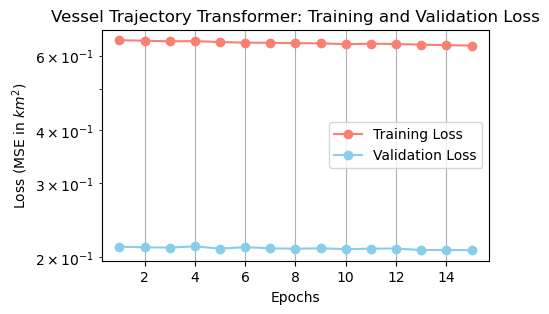

In [10]:
import matplotlib.pyplot as plt
def plot_training_history(history):
    """
    Plots the training and validation MSE loss over epochs.
    """
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(5, 3))
    plt.plot(epochs, train_loss, 'o-', label='Training Loss', color='salmon')
    plt.plot(epochs, val_loss, 'o-', label='Validation Loss', color='skyblue')
    
    plt.title('Vessel Trajectory Transformer: Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE in $km^2$)')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    
    # If your loss values are very small, a log scale helps visibility:
    # plt.yscale('log')
    
    plt.savefig('training_curve.png')
    print("Training curve saved as 'training_curve.png'")

# After training:
plot_training_history(history)

### evaluate on test set

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def evaluate_and_plot_errors(model, test_loader, device='cuda'):
    model.eval()
    # Initialize an accumulator for errors at each of the 20 steps
    # Using 64-bit float for precision over the large test set
    total_errors = np.zeros(20, dtype=np.float64)
    total_samples = 0

    print(f"Evaluating on {len(test_loader.dataset):,} test windows...")

    with torch.no_grad():
        for inputs, targets in test_loader:
            # 1. Prepare data
            # Slice targets to just (lat_rel_km, lon_rel_km)
            targets = targets[:, :, :2].to(device)
            inputs = inputs.to(device)

            # 2. Forward pass
            # pred_pos shape: (Batch, 20, 2)
            pred_pos = model(inputs)

            # 3. Calculate Euclidean Distance Error per step
            # Calculate (x_p - x_t)^2 + (y_p - y_t)^2
            squared_diff = (pred_pos - targets) ** 2 # (Batch, 20, 2)
            # Sum across the last dimension (x and y) and take square root
            # dist_error shape: (Batch, 20)
            dist_error = torch.sqrt(torch.sum(squared_diff, dim=-1))

            # 4. Accumulate errors per time step
            total_errors += dist_error.sum(dim=0).cpu().numpy()
            total_samples += inputs.size(0)

    # Calculate final mean error for each step
    mean_distance_errors = total_errors / total_samples

    return mean_distance_errors

# Call the evaluation
# mde_per_step = evaluate_and_plot_errors(transformer_model, test_loader, device=device)

In [12]:
try:
    mde_per_step = np.load(f'trained_models/mde_transformer_{model_idx}.npy')
except:
    mde_per_step = evaluate_and_plot_errors(transformer_model, test_loader, device=device)
    np.save(f'trained_models/mde_transformer_{model_idx}.npy', mde_per_step)
    print(f"MDE data saved to trained_models/mde_transformer_{model_idx}.npy")

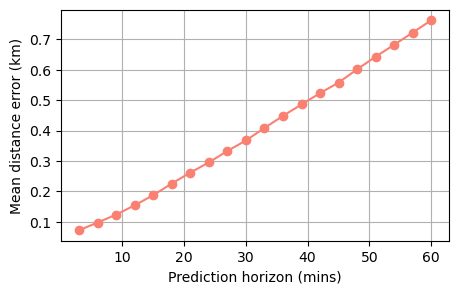

In [13]:
plt.figure(figsize=(5,3))
time_horizon = np.arange(3, 61, 3)
plt.plot(time_horizon, mde_per_step, '-o', color='salmon')
plt.xlabel('Prediction horizon (mins)')
plt.ylabel('Mean distance error (km)')
plt.grid(True)

In [14]:
mde_per_step

array([0.07238303, 0.09754245, 0.12364005, 0.15422251, 0.1875938 ,
       0.22571561, 0.26179966, 0.29520503, 0.33280834, 0.36740369,
       0.40838204, 0.44832306, 0.48587646, 0.52314579, 0.55788001,
       0.60139055, 0.64306465, 0.68234781, 0.72236619, 0.7628457 ])

In [15]:
mlp_mde = np.loadtxt('mlp_horizon_errors.csv', 
           skiprows=1, delimiter=',')[:, 2]

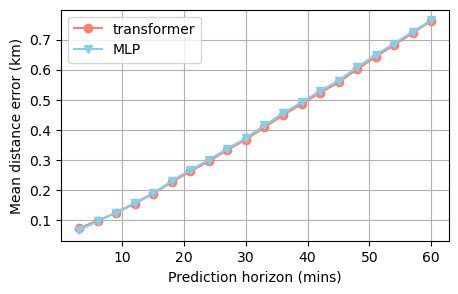

In [16]:
mde1 = np.load(f'trained_models/mde_transformer_{model_idx}.npy')
# mde2 = np.load('trained_models/mde_transformer_20260509_230356.npy')
mde2 = mlp_mde

plt.figure(figsize=(5,3))
time_horizon = np.arange(3, 61, 3)
plt.plot(time_horizon, mde1, '-o', color='salmon', label='transformer')
plt.plot(time_horizon, mde2, '-v', color='skyblue', label='MLP')
plt.xlabel('Prediction horizon (mins)')
plt.ylabel('Mean distance error (km)')
plt.grid(True)
plt.legend()